# Perimeter Creation Using HMS Shapefiles

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import geopandas as gpd
import json
import pandas as pd
import os
import glob
import pathlib as pl
import re
import shapely as sp
import numpy as np
import fiona
# import ipywidgets as widgets
import ast
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
#set home path
os.chdir('..')
os.chdir('..')

home = pl.Path(os.getcwd())
print(home)

#location of all larger functions required for the perimeter delineation
from src.perimeter_functions_edited import *
from _pyfile_notebook_edits.schematics_to_perimeters_inputs import *

c:\_code\hms_to_ras_sst


#### Reading and Merging Files by Feature Class

In [4]:
#identify all huc8 gdb in our input folders and collect their paths
huc8_gdb = glob.glob(str(inputs)+input_file_type, recursive=False)
print('Quantity of huc8s:', len(huc8_gdb))
assert len(huc8_gdb) > 0, 'No input files found. Please check the inputs folder and file type variable.'

Quantity of huc8s: 15


In [5]:
#reading from geodatabases to create a gdf per each feature requested. ex. one gdf for junctions, one for reaches, etc.
junctions = locate_string_gdb_to_concat_gdf(huc8_gdb,"Junction")
reaches = locate_string_gdb_to_concat_gdf(huc8_gdb,"Reach")
subbasins = locate_string_gdb_to_concat_gdf(huc8_gdb,"Subbasin")
sinks = locate_string_gdb_to_concat_gdf(huc8_gdb,"Sink")

print(f"There are {len(junctions)} Junctions, {len(reaches)} Reaches, {len(subbasins)} Subbasins, and {len(sinks)} Sinks") 

After searching through 15 geodatabases/geopackages, there are now 4378 "Junction" features
After searching through 15 geodatabases/geopackages, there are now 4378 "Reach" features
After searching through 15 geodatabases/geopackages, there are now 6965 "Subbasin" features
After searching through 15 geodatabases/geopackages, there are now 16 "Sink" features
There are 4378 Junctions, 4378 Reaches, 6965 Subbasins, and 16 Sinks


In [6]:
#review for duplicate naming for the read files
duplicate_junctions = junctions['name'].duplicated()
duplicate_reaches = reaches['name'].duplicated()
duplicate_subbasins = subbasins['name'].duplicated()
duplicate_sinks = sinks['name'].duplicated()

assert True not in duplicate_junctions.to_list(), 'Duplicate Junctions: Unable to continue. Must review Information.'
assert True not in duplicate_reaches.to_list(), 'Duplicate Reaches: Unable to continue. Must review Information.'
assert True not in duplicate_subbasins.to_list(), 'Duplicate Subbasins: Unable to continue. Must review Information.'
assert True not in duplicate_sinks.to_list(), 'Duplicate Sinks: Unable to continue. Must review information.'

In [19]:
subbasins.crs

<Derived Projected CRS: PROJCS["USA_Contiguous_Albers_Equal_Area_Conic_USG ...>
Name: USA_Contiguous_Albers_Equal_Area_Conic_USGS_version
Axis Info [cartesian]:
- [east]: Easting (US survey foot)
- [north]: Northing (US survey foot)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Successfully loaded shapefile with 6965 features
Converting from PROJCS["USA_Contiguous_Albers_Equal_Area_Conic_USGS_version",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219],AXIS["Easting",EAST],AXIS["Northing",NORTH]] to EPSG:4326


c:\Users\magomez\.conda\envs\regularhome\lib\site-packages\geopandas\plotting.py:679: RuntimeWarning: invalid value encountered in cos
  ax.set_aspect(1 / np.cos(y_coord * np.pi / 180))


ValueError: aspect must be finite and positive 

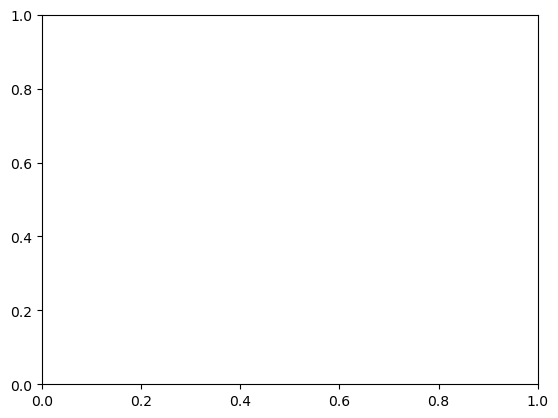

In [10]:
#retrieve the HUC10s that intersect and surround the data provided.
hucs = retrieve_wbd_huc10_intersections(subbasins,outputs)
#spatial join junctions with huc10s from WBD database 
coord = junctions.crs
hucs_df = hucs.to_crs(coord)

joined_gdf = gpd.sjoin(junctions, hucs_df, how='left', predicate='intersects')
junctions['huc'] = joined_gdf['huc10']

In [ ]:
#export spatial join file of the junctions - will be needed for assigning nearest downstream junction to sinks
joined_gdf.to_file(working_outputs/"junctions_spatial_joined.shp")

#export sinks to shapefile - this will be needed to help identify the nearest downstream junction to the sink on ArcGIS. Gather a list of their names for future use
sinks.to_file(working_outputs/"all_sinks_temp.shp")
sinks_list = [x for x in sinks['name'].to_list()]

#temporary reach export for review during procedure
reaches.to_file(working_outputs/"all_reaches_temp.shp")

C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\1405052664.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  joined_gdf.to_file(working_outputs/"junctions_spatial_joined.shp")
C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\1405052664.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sinks.to_file(working_outputs/"all_sinks_temp.shp")
C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\1405052664.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  reaches.to_file(working_outputs/"all_reaches_temp.shp")


In [ ]:
#Create a field for the junctions gdf: This will note how many junctions are upstream but still lie within the same HUC10 from the wbd. 
#Highest count will be out downstream junction for that Huc10
junctions['connect_count'] = 'None'
junctions['ds_junc_status'] = False

## Identifying DS_Junction Per HUC10

In [ ]:
#Gather a list of all unique values from the "huc" column. These are the HUC10s that the data received lie within
huc10s = junctions['huc'].unique()

In [ ]:
#Create dictionaries showing connection between junctions and reaches
junc_to_reach = junctions.set_index('name').to_dict()['Downstream']
reach_to_junc = reaches.set_index('name').to_dict()['Downstream']

#HUC8 sinks currently have no connection to any other junctions or reaches. The sinks will have a downstream junction added only in the dictionaries here for the purpose of creating a network that terminates at the end of the system overall.
#This portion will add connections only to the dictionaries by referencing a "ghost" reach that connects the sinks to the nearest junction as dictated by the user. 
sinks_to_junction = dict()

print('Prepare to type the nearest junction downstream of the sink WITHOUT any space or character before or after it. Ex. HUC_000_J_123.\nIf the sink is the most downstream, type OUT.')
for sink in sinks_list:
    user_input_connection = input(f'Please review sink {sink}.')
    sinks_to_junction[sink] = user_input_connection
    leaving_system = re.search(r'(?i)out', user_input_connection)
    
    if leaving_system:
        text = 'The sink is the most downstream'
        print(f"\033[31m{text}\033[0m")
    
    junc_to_reach[sink] = f'r_connect_{sink}_to_'+user_input_connection
    reach_to_junc[f'r_connect_{sink}_to_'+user_input_connection] = user_input_connection

# print(junc_to_reach,'\n',reach_to_junc)

Prepare to type the nearest junction downstream of the sink WITHOUT any space or character before or after it. Ex. HUC_000_J_123.
If the sink is the most downstream, type OUT.


Please review sink HUC_101_Sink_0. OUT


The sink is the most downstream


Please review sink HUC_201_Sink_370. HUC_202_J_4411
Please review sink HUC_202_Sink_0. HUC_207_J_1720
Please review sink HUC_203_Sink_0. HUC_202_J_1782
Please review sink HUC_204_Sink_0. HUC_202_J_1833
Please review sink HUC_205_Sink_0. HUC_202_J_2511
Please review sink HUC_206_Sink_0. HUC_207_J_590
Please review sink HUC_207_Sink_0. OUT


The sink is the most downstream


Please review sink HUC_208_Sink_2082. OUT


The sink is the most downstream


In [ ]:
#record of the connection between sinks and downstream junctions. This is not to be used anywhere in particular but can be referenced later on. There could be changes between initial and final schematic naming - though that should not be common.
with open(working_outputs/'sink_to_junction.json','w') as outfile:
    json.dump(sinks_to_junction,outfile, indent=2)

In [ ]:
#from each unique huc10 identified from the spatial join with the WBD, all junctions will be networked and the junction with the maximum connections upstream within a huc10 will be labeled the downstream junction.
for huc in huc10s:
    #filter all the junctions that intersect with the huc10 of interest
    huc10_j = junctions.loc[junctions['huc'] == huc]['name'].tolist()
    
    #count how many junctions are upstream of each one to identify the most downstream junction. it will only count them if they are spatially found within the same WBD HUC10.
    for junction in huc10_j:
        us_count = count_up_within_list_limiting(junction,huc10_j,junc_to_reach,reach_to_junc)
        #assign the final upstream count value in complete junction dataframe
        junctions.loc[junctions['name'] == junction, 'connect_count'] = us_count
    
    #indicate which of the junctions is the ds_junc for that HUC by "TRUE" in ds_junc_status field. It will appear as 1 when exported as a shapefile
    huc10_j_df = junctions.loc[(junctions['huc'] == huc)]
    ds_junc_max = huc10_j_df['connect_count'].max()
    junctions.loc[(junctions['connect_count'] == ds_junc_max) & (junctions['huc'] == huc), 'ds_junc_status'] = True
    
    #there should only be one downstream junction per huc10. A warning will appear if otherwise - this will require a manual adjustment.
    temp_ds = junctions.loc[(junctions['huc'] == huc) & (junctions['ds_junc_status'] == True)]
    
    if len(temp_ds) > 1:
        print(f'HUC10 {huc} has multiple downstream junctions assigned. One will temporarily be selected.')
        identified_ds_juncs = temp_ds['name'].values.tolist()
        junctions.loc[(junctions['name'] == identified_ds_juncs[0]) & (junctions['huc'] == huc), 'ds_junc_status'] = False
    else:
        pass

#After all downstream junctions are assigned, the junctions will be put into a network no longer relying on the spatial relationship with the WBD.
junctions = network_up(huc10s,junctions,junc_to_reach,reach_to_junc)
print('All HUC10s have a downstream junction')

All HUC10s have a downstream junction


In [ ]:
#filter all of the ds_junctions and create dictionary with the name and assigned HUC10 of the downstream junction. This dictionary will continue to be updated throughout the rest of the jupyter notebook
ds_junctions = junctions.loc[junctions['ds_junc_status'] == True]
ds_junctions_dict = ds_junctions.set_index('name').to_dict()['huc']

In [ ]:
#with the downstream junctions, we can now find which HUC10s connect to which HUC10s
huc_to_huc = dict()
for ds_junc in ds_junctions_dict.keys():
    #This will be done by identifying the downstream junction, and then which HUC10 that junction has been assigned to.
    down_junc_first = move_down(ds_junc,junc_to_reach,reach_to_junc)
    
    #if the sink is downstream of a ds_junction it will be skipped. The next junction will be set
    if down_junc_first[0] in sinks_list:
        down_junc = junctions.loc[(junctions['name'].isin(move_down(down_junc_first[0],junc_to_reach,reach_to_junc)))]
        found_sink2 = re.search(r'(?i)sink', move_down(down_junc_first[0],junc_to_reach,reach_to_junc)[0])
        assert not found_sink2, 'A sink identified after a sink. Troubleshoot.'
    else:
        down_junc = junctions.loc[(junctions['name'].isin(down_junc_first))]
    
    down_huc = down_junc['huc'].to_list()
    if len(down_huc)!= 0:
        huc_to_huc[ds_junctions_dict[ds_junc]] = down_huc[0]
    else:
        huc_to_huc[ds_junctions_dict[ds_junc]] = ''

#The missing_connection list is to be aware of the HUC10s that don't have connectivitiy to other HUC10s due to being located at the sink of the HMS model.
#The HUC10s in this list should match the locations of the sinks that lead out of the system of inputs provided.
missing_connections = [k for k,v in huc_to_huc.items() if v == '']
print('Review information if following hucs not where the complete project network ends according to sinks',missing_connections)

Review information if following hucs not where the complete project network ends according to sinks ['1009010107', '1009010108', '1009020703']


## Designate Junctions per HUC10

In [ ]:
hucs_df  #variable assigned to hold WBD perimeters around our work space with the same coordinate system as subbasins
subbasins = subbasins.to_crs(coord)
#the area function would create the area in square feet if projection set to Feet

crs_info = subbasins.crs
print(f"GeoDataFrame CRS for subbasins: {crs_info}")
# Inspect units
print('Units are in:',crs_info.axis_info[0].unit_name)

#convert subbasin area information to acres for comparison with HUC10 original size.
if crs_info.axis_info[0].unit_name == 'metre':
    subbasins['mod_area_acres'] = subbasins.geometry.area/4047
elif crs_info.axis_info[0].unit_name == 'US Survey feet':
    subbasins['mod_area_acres'] = subbasins.geometry.area/43560
else:
    print('The units of the geodataframe are neither metres nor US Survey Feet. Please review.')

GeoDataFrame CRS for subbasins: EPSG:5070
Units are in: metre


In [ ]:
subbasins.to_file(working_outputs/"subbasins_draft.shp")

C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\1901563134.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  subbasins.to_file(working_outputs/"subbasins_draft.shp")


In [ ]:
#The goal of the following is to identify all of the junctions that belong to the huc10 associated with the downstream junction
#One obstacle is that the ds junctions must not gather too much of another HUC10 in terms of area in an effort to preserve the overal shape of the WBD HUC10s boundaries

#below are the acceptable range for a new perimeters approximate area vs. the original WBD perimeter area
upper_pct = 1.15
lower_pct = 0.85

#if a ds_junction results in less than the below amount of original area for a HUC10, the ds_junction will simply be removed and the junction itself will belong to another network.
incomplete_huc10 = 0.05
no_longer_delineated = set()

#the following HUCs cannot have their upstream or downstream BCs altered due to exiting the system. They should have a sink assigned as the downstream junction in a later step
locked_ds_hucs = missing_connections

#dictionary that will have updated pct values based on the junctions assigned
huc_pct = dict()

#temporary value set to 0
for huc in huc10s:
    huc_pct[huc] = 0

##########This portion will evaluate the percentage of assigned subbasin areas to that of the original WBD

#collect all subbasins upstream of a ds junctions network and compare the combined area to that of the original assigned HUC10 from the WBD.
for huc in huc10s:
    huc_juncs = junctions.loc[junctions['huc'] == huc]
    subbasin_huc = subbasins.loc[subbasins['Downstream'].isin(huc_juncs['name'])]

    sub_area = subbasin_huc['mod_area_acres'].sum()
    huc_wbd = hucs_df.loc[hucs_df['huc10'] == huc]
    temp_pct = sub_area/huc_wbd['areaacres']
    huc_pct[huc] = temp_pct.to_list()[0]

all_within = all_in_range(list(huc_pct.values()),lower_pct,upper_pct)
print('Current percentages fit within range:',all_within)
if all_within == True:
    print('No fixes needed')
else:
    ################## Identify every HUC10 that may pose an issue with the current assignments given. review these later on.
    may_require_attention = set()
    for k,v in huc_pct.items():
        if k not in locked_ds_hucs:
            if v < lower_pct and v > incomplete_huc10:
                may_require_attention.add(k)
            if v > upper_pct:
                may_require_attention.add(k)

            # This part will remove ds_junction assignment for hucs that seem incomplete in terms of subbasins to overall WBD HUC10 area
            if v < incomplete_huc10:
                print('it will be assumed that the ds_junction for huc',k,'is not needed. it will be removed from ds junctions')
                junctions.loc[(junctions['huc'] == k) & (junctions['ds_junc_status'] == True), 'ds_junc_status'] = False
                ds_junctions = junctions.loc[junctions['ds_junc_status'] == True]
                indices = np.where(huc10s == k)[0]
                huc10s = np.delete(huc10s, indices)
                no_longer_delineated.add(k)
        else:
            print(f'HUC10 {k} will not have it\'s downstream junction altered. This HUC10 outflow is leaving the network. Change to the respective sink in later step')

    for item in no_longer_delineated:
        del huc_pct[item]

    # print('Current percentages:',huc_pct)
    print('HUC10s that require fixing:',may_require_attention,'\n')
    
    for fix in may_require_attention:
        percent = huc_pct[fix]
        print(f'{fix}: {str(percent)}')

Current percentages fit within range: False
HUC10 1009010108 will not have it's downstream junction altered. This HUC10 outflow is leaving the network. Change to the respective sink in later step
HUC10 1009010107 will not have it's downstream junction altered. This HUC10 outflow is leaving the network. Change to the respective sink in later step
HUC10 1009020703 will not have it's downstream junction altered. This HUC10 outflow is leaving the network. Change to the respective sink in later step
HUC10s that require fixing: {'1009020202', '1009020203', '1009020702', '1009020301', '1009020701', '1009020303', '1009020502', '1009020501', '1009020205', '1009020603', '1009020206'} 

1009020202: 0.6034425643944352
1009020203: 1.8728962605087063
1009020702: 1.2827507038160462
1009020301: 1.2744171902740904
1009020701: 0.6927809571455821
1009020303: 0.7633173358963348
1009020502: 1.4699555564731273
1009020501: 0.6769505076243434
1009020205: 0.5587163094376918
1009020603: 0.7702035260684942
10090

In [ ]:
#rerun the network of junctions to ensure that they address any changes, ex. if a HUC10 was no longer delineated according to ratio in cell above
junctions = network_up(huc10s,junctions,junc_to_reach,reach_to_junc)
#remove the outdated us_count field and re-export the junction shapefile to hold the correct huc10 assignments
junctions = junctions.drop(columns = 'connect_count')
junctions.to_file(working_outputs/"junctions_draft.shp")

#export the latest downstream junction assignments
ds_junctions = junctions.loc[junctions['ds_junc_status'] == True]
ds_junctions_dict = ds_junctions.set_index('huc').to_dict()['name']
ds_junctions.to_file(working_outputs/"ds_junctions_draft.shp")

C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\2893282644.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  junctions.to_file(working_outputs/"junctions_draft.shp")
C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\2893282644.py:10: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  ds_junctions.to_file(working_outputs/"ds_junctions_draft.shp")


## Subbasin Assignments and Cleanup

In [ ]:
#Prepare a gdf with both the sinks and junctions - this will allow for the designation of ds junctions as needed. Closed basin and the most downstream will require the downstream junction
#to be a sink.
sink_junctions = pd.concat([sinks,junctions], ignore_index=True)
#instead of relying on the junction gdf for subbasin assignments, a joint gdf of the sinks and the junctions will be used as some subbasins are connected to sinks instead of junctions.

In [ ]:
#if the HUC10 is at the downstream end of the scoped area and has a sink, it now needs to be reassigned to the sink instead of the downstream junction
review_huc10_dsj = set()
review_huc10_dsj.update(missing_connections)

#the ds_junc_status field is only reset in the gdf, updates will be made into a dictionary and later updated as needed.
sink_junctions['ds_junc_status'] = False

huc10_fix_input = input(f"Please review the provided downstream junctions and junction assignments on ArcGIS. Provide, as a list, the HUC10s that should be altered. For example, type ['1234567890','1234567891'] \nHUC10 {missing_connections} is included by default.")
huc10_fix = ast.literal_eval(huc10_fix_input)
review_huc10_dsj.update(huc10_fix)

print('Prepare to type the new DS Junction WITHOUT any space or character before/after it. For example, type HUC_###_J_### if that is the new downstream junction for the HUC10 in review. \nIf the outflow from the HUC10 is leaving the system, change it to the most downstream sink.')
for review in review_huc10_dsj:
    fixed_dsj_input = input(f"Type the new downstream junction for the model domain or huc10 {review}.")
    new_dsj = fixed_dsj_input
    sink_junctions.loc[sink_junctions['name'] == new_dsj, 'huc'] = review
    ds_junctions_dict[review] = new_dsj

#create a new network based on the updated ds junctions.
huc10s = [huc for huc,ds in ds_junctions_dict.items() if ds != '']

sink_junctions.loc[sink_junctions['name'].isin(ds_junctions_dict.values()), 'ds_junc_status'] = True
sink_junctions = network_up(huc10s,sink_junctions,junc_to_reach,reach_to_junc)
sink_junctions.to_file(working_outputs/"sink_junctions_draft.shp")

ds_junctions = sink_junctions.loc[sink_junctions['ds_junc_status'] == True]
ds_junctions.to_file(working_outputs/"ds_sink_junctions_draft.shp")

Please review the provided downstream junctions and junction assignments on ArcGIS. Provide, as a list, the HUC10s that should be altered. For example, type ['1234567890','1234567891'] 
HUC10 ['1009010107', '1009010108', '1009020703'] is included by default. ['1009020807','1009020806']


Prepare to type the new DS Junction WITHOUT any space or character before/after it. For example, type HUC_###_J_### if that is the new downstream junction for the HUC10 in review. 
If the outflow from the HUC10 is leaving the system, change it to the most downstream sink.


Type the new downstream junction for the model domain or huc10 1009020703. HUC_207_Sink_0
Type the new downstream junction for the model domain or huc10 1009020807. HUC_208_Sink_2082
Type the new downstream junction for the model domain or huc10 1009020806. HUC_208_J_222
Type the new downstream junction for the model domain or huc10 1009010108. HUC_101_Sink_0
Type the new downstream junction for the model domain or huc10 1009010107. HUC_101_J_1340


C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\1092922690.py:24: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sink_junctions.to_file(working_outputs/"sink_junctions_draft.shp")
C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\1092922690.py:27: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  ds_junctions.to_file(working_outputs/"ds_sink_junctions_draft.shp")


In [ ]:
#Alter subbasins gdf to include a field with the HUC10 model domain they have been assigned to
subbasins_assigned = subbasins.copy()
subbasins_assigned['huc_mod'] = ''

for huc in huc10s:
    huc_juncs = sink_junctions.loc[sink_junctions['huc'] == huc]
    subbasins_assigned.loc[subbasins_assigned['Downstream'].isin(huc_juncs['name']), 'huc_mod'] = huc

In [ ]:
huc_to_huc

{'1009010106': '1009010107',
 '1009010107': '',
 '1009010102': '1009010104',
 '1009010103': '1009010104',
 '1009010101': '1009010104',
 '1009010104': '1009010105',
 '1009010105': '1009010108',
 '1009010108': '',
 '1009020103': '1009020202',
 '1009020101': '1009020102',
 '1009020102': '1009020202',
 '1009020207': '1009020209',
 '1009020201': '1009020202',
 '1009020202': '1009020203',
 '1009020203': '1009020204',
 '1009020204': '1009020205',
 '1009020205': '1009020206',
 '1009020206': '1009020208',
 '1009020208': '1009020209',
 '1009020209': '1009020701',
 '1009020301': '1009020302',
 '1009020302': '1009020303',
 '1009020303': '1009020304',
 '1009020304': '1009020202',
 '1009020401': '1009020403',
 '1009020402': '1009020403',
 '1009020403': '1009020202',
 '1009020501': '1009020502',
 '1009020502': '1009020503',
 '1009020503': '1009020208',
 '1009020603': '1009020604',
 '1009020602': '1009020604',
 '1009020601': '1009020604',
 '1009020604': '1009020605',
 '1009020605': '1009020701',
 '100

## Export Final Assignments

In [ ]:
#FOR UNASSIGNED SUBBASINS MANUAL ENTRY IS REQUIRED. This portion will identify if any subbasins have not been assigned yet and plot them for visual aid in identifying them.
subbasins_assigned_empty = subbasins_assigned.loc[subbasins_assigned['huc_mod'] == '']
print('amount of unassigned subbasins:',len(subbasins_assigned_empty))

if len(subbasins_assigned_empty) != 0:
    for index,row in subbasins_assigned_empty.iterrows():
        print('unassigned subbasin:',row['name'],'goes downstream to:',row['Downstream'])
    print('Please review why the subbasins have not been assigned. You must alter the shapefiles as needed to not exclude the subbasin assignment.')

amount of unassigned subbasins: 0


In [ ]:
#Now that all subbasins have been assigned - re-export the subbasin assigned shapefile."
subbasins_assigned.to_file(outputs/"subbasins_assigned_final.shp")
sink_junctions.to_file(outputs/"sink_junctions_final.shp")
ds_junctions.to_file(outputs/"ds_sink_junctions_final.shp")

C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\3226899616.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  subbasins_assigned.to_file(outputs/"subbasins_assigned_final.shp")
C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\3226899616.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sink_junctions.to_file(outputs/"sink_junctions_final.shp")
C:\Users\magomez\AppData\Local\Temp\ipykernel_20708\3226899616.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  ds_junctions.to_file(outputs/"ds_sink_junctions_final.shp")


# END